# 08a: Pre-train NN Surrogate

Builds the bundle that the downstream inference notebooks ([08b](08b_rwmh_three_way_baseline.ipynb), [08c](08c_nuts_closedform_validation.ipynb), 08d) consume for Bayesian inference (Bayesian.md §3.4.1 Steps 1-2). The bundle has four files saved under `outputs/notebooks/08a_pretrain_nn_surrogate/`:

| File | Content |
|---|---|
| `shac_full_frictionless.panel.npz` | Observation-ready panel `(y, log_k, log_k_next)` with η on `y` and ξ on `log_k` baked in. Latent z is NOT stored (eliminates leakage risk into inference). |
| `shac_full_frictionless.weights.h5` | SHAC-trained NN surrogate policy (optimal policy φ; independent of residual params, no retrain needed when DGP residuals change) |
| `shac_full_frictionless.weights.h5.normalizer.npz` | Normalizer state for the NN |
| `shac_full_frictionless.meta.json` | Env config, bounds, ground-truth β (all 7 params), training metadata |

Cache invalidation is manual. Flip `REGENERATE_PANEL=True` if you change `BETA_TRUE` (including the four residual params) or panel dimensions; flip `RETRAIN_NN=True` if you change the NN config or bounds.

## Section 0: Setup

In [1]:
from pathlib import Path
import json
import os
import sys
import time
import warnings
from dataclasses import asdict

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
warnings.filterwarnings("ignore", message=r".*does not produce the same series as CPU implementation.*")
warnings.filterwarnings("ignore", message=r".*casting an input of type complex64.*")

_REPO_ROOT = None
for _rr_candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_rr_candidate / "src" / "v2").exists():
        _REPO_ROOT = _rr_candidate
        break
if _REPO_ROOT is None:
    import importlib.util as _rr_ilu
    _rr_spec = _rr_ilu.find_spec("src.v2")
    if _rr_spec is not None and _rr_spec.origin is not None:
        _REPO_ROOT = Path(_rr_spec.origin).resolve().parents[2]
if _REPO_ROOT is None:
    raise RuntimeError("Could not find repo root containing src/v2.")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

USE_GPU = False
import tensorflow as tf
if not USE_GPU:
    tf.config.set_visible_devices([], "GPU")
tf.get_logger().setLevel("ERROR")

from src.v2.environments.basic_investment import EconomicParams, ShockParams
from src.v2.environments.parameterized_basic_investment import ParameterizedBasicInvestmentEnv
from src.v2.estimation.bayesian_basic_investment import (
    derive_env_bounds_from_panel,
    diagnose_nn_linear_slope,
    generate_frictionless_panel,
    load_policy_with_normalizer,
    save_policy_with_normalizer,
)
from src.v2.estimation.beta_sampler import BetaSampler, DEFAULT_UNIFORM_BOUNDS
from src.v2.networks.policy import ParameterizedPolicyNetwork
from src.v2.networks.state_value import ParameterizedStateValueNetwork
from src.v2.trainers.config import SHACConfig, NetworkConfig, OptimizerConfig
from src.v2.trainers.shac_param import train_shac_param
from src.v2.evaluation.policies import restore_selected_snapshot
from src.v2.utils.seeding import fold_in_seed

print(f"tf: {tf.__version__}")
np.set_printoptions(precision=4, suppress=True)

/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


tf: 2.16.2


## Section 1: Configuration

Notebook-level switches and constants. All cache decisions live here.

In [ ]:
MASTER_SEED      = (20, 26)
REGENERATE_PANEL = True
RETRAIN_NN       = False

# Panel dimensions, sized for the largest downstream consumer (08d FULL profile).
N_FIRMS, HORIZON, BURN_IN = 200, 40, 30

# Calibrated economic parameters (fixed, never inferred).
INTEREST_RATE, DEPRECIATION_RATE, MU = 0.04, 0.10, 0.0

# Ground-truth 7-param vector (Bayesian.md §2.3). The four residual params
# describe the DGP's measurement and policy-deviation structure:
#   production_mean = 0.05: small systematic production misspecification
#                           (offset from the Normal(0, 0.1) prior mean of 0).
#   production_std  = 0.05: small measurement noise on log revenue.
#   investment_mean = -0.10: firms systematically under-invest by ~10%
#                            vs the model-implied optimal capital.
#   investment_std  = 0.05: noise around that systematic gap.
# All seven truths are deliberately offset from their prior means so that a
# stuck inference chain (sitting near its prior-drawn init) cannot
# coincidentally land at the truth. Previous truth (alpha=0.5, rho=0.5,
# production_mean=0) coincided too closely with the Uniform/Normal prior
# centres on three params, making 08b validation ambiguous.
BETA_TRUE = dict(
    alpha=0.50, rho=0.50, sigma_epsilon=0.24,
    production_mean=0.05,  production_std=0.05,
    investment_mean=-0.10, investment_std=0.05,
)

# SHAC NN surrogate: architecture + training config.
NN = dict(n_layers=4, n_neurons=256, n_train=65536, batch_size=256,
          shac_steps=8000, n_critic=16, plateau_patience=16)

OUTPUT_DIR  = _REPO_ROOT / "outputs" / "notebooks" / "08a_pretrain_nn_surrogate"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BUNDLE_BASE = OUTPUT_DIR / "shac_full_frictionless"
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

## Section 2: Panel (simulated or loaded)

The panel `(k, z)` is the data the inference will fit. For frictionless validation we simulate from the closed-form policy at `BETA_TRUE`. For real-data deployment, replace the simulation branch with a loader that returns the same `{"k": ..., "z": ...}` dict with arrays of shape `(N_FIRMS, HORIZON+1)`.

In [3]:
PANEL_FILE = BUNDLE_BASE.with_suffix(".panel.npz")

if REGENERATE_PANEL or not PANEL_FILE.exists():
    # Validation path: simulate observation-ready panel from closed-form at
    # BETA_TRUE. The panel contains (y, log_k, log_k_next) with η on y and
    # ξ on log k baked in at the DGP's (production/investment mean and std).
    panel = generate_frictionless_panel(
        beta=BETA_TRUE,
        interest_rate=INTEREST_RATE, depreciation_rate=DEPRECIATION_RATE, mu=MU,
        n_firms=N_FIRMS, horizon=HORIZON, burn_in=BURN_IN,
        seed=fold_in_seed(MASTER_SEED, "panel"),
    )
    # Production path placeholder: replace the simulate call above with
    #   panel = load_real_panel(...)   # {"y": (N, T), "log_k": (N, T), "log_k_next": (N, T)}
    np.savez(PANEL_FILE, **panel)
    print(f"Simulated and cached panel at {PANEL_FILE.name}")
else:
    panel = dict(np.load(PANEL_FILE))
    print(f"Loaded cached panel from {PANEL_FILE.name}")

# Sanity check: panel shapes and empirical residual statistics.
print(f"  shapes: y={panel['y'].shape}, log_k={panel['log_k'].shape}, "
      f"log_k_next={panel['log_k_next'].shape}")
print(f"  log_k range [{panel['log_k'].min():.2f}, {panel['log_k'].max():.2f}]")

# Recover latent log z from y assuming the DGP's production residual structure;
# then compare log k_next against the noiseless closed-form prediction to verify
# the investment residual matches (investment_mean, investment_std).
_a, _r, _s = BETA_TRUE["alpha"], BETA_TRUE["rho"], BETA_TRUE["sigma_epsilon"]
_kappa = (np.log(_a) + 0.5 * _s ** 2 - np.log(INTEREST_RATE + DEPRECIATION_RATE)) / (1.0 - _a)
_slope = _r / (1.0 - _a)
_log_z_recovered = (panel["y"] - _a * panel["log_k"] - BETA_TRUE["production_mean"])
_inv_residual    = panel["log_k_next"] - (_slope * _log_z_recovered + _kappa)
print(f"  empirical investment residual: mean={_inv_residual.mean():+.4f} "
      f"(truth {BETA_TRUE['investment_mean']:+.4f}), "
      f"std={_inv_residual.std():.4f} (truth {BETA_TRUE['investment_std']:.4f})")

Simulated and cached panel at shac_full_frictionless.panel.npz
  shapes: y=(200, 40), log_k=(200, 40), log_k_next=(200, 40)
  log_k range [1.43, 3.53]
  empirical investment residual: mean=-0.1002 (truth -0.1000), std=0.0709 (truth 0.0500)


## Section 3: Bounds and environment

Bounds derived from the panel's k range (with multiplicative margin) and a fixed log-z half-width. The env wraps these bounds plus the calibrated economic parameters.

In [4]:
bounds = derive_env_bounds_from_panel(np.exp(panel["log_k"]), k_margin=1.2, log_z_half_width=1.0, mu=MU)
print(f"Bounds: {bounds}")

nominal_econ = EconomicParams(
    interest_rate=INTEREST_RATE, depreciation_rate=DEPRECIATION_RATE,
    production_elasticity=BETA_TRUE["alpha"], cost_convex=0.0, cost_fixed=0.0,
)
nominal_shocks = ShockParams(rho=BETA_TRUE["rho"], sigma=BETA_TRUE["sigma_epsilon"], mu=MU)
param_env = ParameterizedBasicInvestmentEnv(
    nominal_econ=nominal_econ, nominal_shocks=nominal_shocks, bounds=bounds,
)
beta_sampler = BetaSampler(freeze_dims=(3, 4))
print(f"BetaSampler bounds = {beta_sampler.uniform_bounds}")

Bounds: {'k_min': 3.4696559857106477, 'k_max': 40.91473813559812, 'z_min': 0.36787944117144233, 'z_max': 2.718281828459045}
BetaSampler bounds = ((0.2, 0.85), (0.1, 0.9), (0.05, 0.6), (0.0, 1.5), (0.0, 0.15))


## Section 4: NN surrogate (cached)

SHAC-trained NN over (state × β). Loads cached weights unless `RETRAIN_NN=True`. The hard MAE gate (held-out error < 2% of k-range) aborts if the NN is too inaccurate to use downstream. The slope diagnostic at ground-truth β is informational; the authoritative NN-error readout is the σ_ξ posterior in 08d.

In [5]:
# Held-out validation set (frozen across training).
N_VAL = 1024
val_dataset = {
    "s_endo": param_env.sample_initial_endogenous(
        N_VAL, seed=tf.constant(fold_in_seed(MASTER_SEED, "train", "val", "s_endo"), tf.int32)),
    "z":      param_env.sample_initial_exogenous(
        N_VAL, seed=tf.constant(fold_in_seed(MASTER_SEED, "train", "val", "z"), tf.int32)),
    "beta":   beta_sampler.sample(
        N_VAL, seed=fold_in_seed(MASTER_SEED, "train", "val", "beta")),
}
_val_s       = param_env.merge_state(val_dataset["s_endo"], val_dataset["z"])
_val_k       = val_dataset["s_endo"][:, 0].numpy()
_val_kp_true = param_env.analytical_kprime(val_dataset["z"], val_dataset["beta"]).numpy().ravel()

def holdout_mae_cb(step, env, policy, value_net, val_dataset):
    a = policy(_val_s, val_dataset["beta"]).numpy().ravel()
    kp_pred = np.clip((1.0 - env.delta_rate) * _val_k + a, env.k_min, env.k_max)
    return {"mae_holdout": float(np.mean(np.abs(kp_pred - _val_kp_true)))}

# Build the policy network.
policy_nn = ParameterizedPolicyNetwork(
    state_dim=param_env.state_dim(), action_dim=param_env.action_dim(), beta_dim=5,
    **param_env.action_spec(),
    n_layers=NN["n_layers"], n_neurons=NN["n_neurons"], seed=(202, 0),
)
policy_nn(tf.zeros((1, param_env.state_dim())), tf.zeros((1, 5)))

WEIGHTS   = BUNDLE_BASE.with_suffix(".weights.h5")
META_FILE = BUNDLE_BASE.with_suffix(".meta.json")

if RETRAIN_NN or not WEIGHTS.exists():
    print("Training SHAC NN surrogate (~60-90 min CPU); cached afterward.")
    value_nn = ParameterizedStateValueNetwork(
        state_dim=param_env.state_dim(), beta_dim=5,
        n_layers=NN["n_layers"], n_neurons=NN["n_neurons"], seed=(203, 0),
    )
    value_nn(tf.zeros((1, param_env.state_dim())), tf.zeros((1, 5)))
    train_seed = fold_in_seed(MASTER_SEED, "train")
    train_dataset = {
        "s_endo": param_env.sample_initial_endogenous(
            NN["n_train"], seed=tf.constant(train_seed, tf.int32)),
        "z":      param_env.sample_initial_exogenous(
            NN["n_train"], seed=tf.constant(fold_in_seed(train_seed, "z0"), tf.int32)),
    }
    ckpt = []
    shac_cfg = SHACConfig(
        n_steps=NN["shac_steps"], batch_size=NN["batch_size"],
        horizon=64, short_horizon=16, n_critic=NN["n_critic"],
        eval_interval=50, master_seed=tuple(train_seed),
        normalize_rewards=False, reward_scale_override=0.05,
        network=NetworkConfig(n_layers=NN["n_layers"], n_neurons=NN["n_neurons"]),
        policy_optimizer=OptimizerConfig(learning_rate=2e-3),
        critic_optimizer=OptimizerConfig(learning_rate=5e-3),
        checkpoint_history=ckpt, snapshot_targets=("policy",),
        monitor="mae_holdout", mode="min",
        plateau_patience=NN["plateau_patience"], plateau_rel_delta=0.02,
        min_steps_before_stop=300,
    )
    t0 = time.time()
    result = train_shac_param(
        param_env, policy_nn, value_nn, beta_sampler, train_dataset,
        val_dataset=val_dataset, config=shac_cfg, eval_callback=holdout_mae_cb,
    )
    train_wall = time.time() - t0
    best_i = int(np.argmin(result["history"]["mae_holdout"]))
    best_step = int(result["history"]["step"][best_i])
    best_mae  = float(result["history"]["mae_holdout"][best_i])
    restore_selected_snapshot(policy_nn, ckpt, best_step)
    save_policy_with_normalizer(policy_nn, WEIGHTS)
    NN_META = {"best_step": best_step, "best_mae": best_mae, "train_wall_sec": float(train_wall)}
    print(f"Trained in {train_wall:.0f}s; best_step={best_step}, best_mae={best_mae:.4f}")
else:
    load_policy_with_normalizer(policy_nn, WEIGHTS)
    if META_FILE.exists():
        _m = json.loads(META_FILE.read_text())
        NN_META = {k: _m.get(k, 0) for k in ("best_step", "best_mae", "train_wall_sec")}
    else:
        NN_META = {"best_step": 0, "best_mae": 0.0, "train_wall_sec": 0.0}
    print(f"Loaded cached NN (best_step={NN_META['best_step']}, best_mae={NN_META['best_mae']:.4f})")

policy_nn.trainable = False

# Hard MAE gate.
mae     = holdout_mae_cb(0, param_env, policy_nn, None, val_dataset)["mae_holdout"]
mae_pct = 100.0 * mae / (param_env.k_max - param_env.k_min)
print(f"Held-out MAE = {mae:.4f} ({mae_pct:.2f}% of k range)")
assert mae_pct < 2.0, f"NN MAE {mae_pct:.2f}% > 2% gate. Retrain with RETRAIN_NN=True."

# Slope diagnostic at ground-truth β (informational).
diag = diagnose_nn_linear_slope(param_env, policy_nn, BETA_TRUE)
print(f"Slope: NN={diag['slope_nn']:.3f}, analytical={diag['slope_analytical']:.3f}, "
      f"rel error={100*diag['rel_error']:.1f}%")

Loaded cached NN (best_step=950, best_mae=0.4233)
Held-out MAE = 0.5061 (1.35% of k range)
Slope: NN=0.831, analytical=1.000, rel error=16.9%


## Section 5: Visual validation

1-D slices of the NN's predicted `k'` against the analytical reference along (α, ρ, σ_ε, z, k). All slices hold the other coordinates at the prior-mean anchor β.

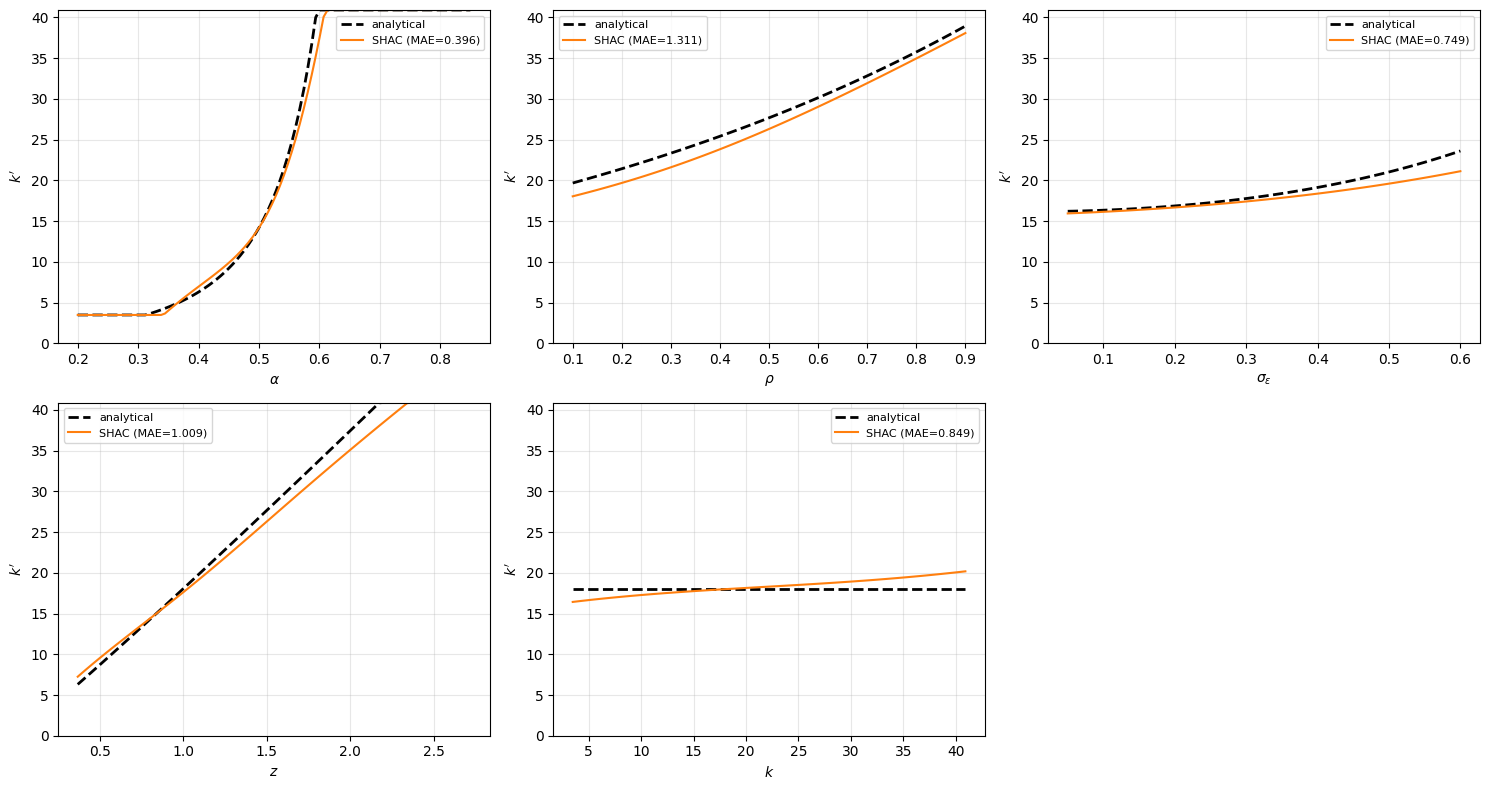

In [6]:
anchor_beta = beta_sampler.prior_mean().numpy().ravel()
fixed_state = np.array([param_env.k_star, float(np.exp(param_env.mu))], dtype=np.float32)
anchor_rho_state = np.array([param_env.k_star, 1.5 * float(np.exp(param_env.mu))], dtype=np.float32)
n_grid = 100

def _kprime_nn(s, beta):
    a = policy_nn(s, beta).numpy().ravel()
    k = s.numpy()[:, 0]
    return np.clip((1.0 - param_env.delta_rate) * k + a, param_env.k_min, param_env.k_max)

def _kprime_true(s, beta):
    return param_env.analytical_kprime(s[:, 1:2], beta).numpy().ravel()

def _sweep_beta(idx, grid, fixed_s):
    beta = np.tile(anchor_beta, (n_grid, 1)).astype(np.float32)
    beta[:, idx] = grid
    s = tf.constant(np.tile(fixed_s, (n_grid, 1)).astype(np.float32))
    return s, tf.constant(beta)

alo, ahi = DEFAULT_UNIFORM_BOUNDS["alpha"]
rlo, rhi = DEFAULT_UNIFORM_BOUNDS["rho"]
slo, shi = DEFAULT_UNIFORM_BOUNDS["sigma_epsilon"]
results = {}
for name, idx, grid, fs in [
    ("alpha",         0, np.linspace(alo, ahi, n_grid), fixed_state),
    ("rho",           1, np.linspace(rlo, rhi, n_grid), anchor_rho_state),
    ("sigma_epsilon", 2, np.linspace(slo, shi, n_grid), fixed_state),
]:
    s, b = _sweep_beta(idx, grid.astype(np.float32), fs)
    nn, tru = _kprime_nn(s, b), _kprime_true(s, b)
    results[name] = (grid, nn, tru, float(np.mean(np.abs(nn - tru))))

# z and k sweeps at anchor β
beta_anchor_tf = tf.constant(np.tile(anchor_beta, (n_grid, 1)).astype(np.float32))
z_grid = np.linspace(param_env.z_min, param_env.z_max, n_grid).astype(np.float32)
s_z = tf.constant(np.stack([np.full(n_grid, param_env.k_star, dtype=np.float32), z_grid], axis=-1))
nn_z, tru_z = _kprime_nn(s_z, beta_anchor_tf), _kprime_true(s_z, beta_anchor_tf)
results["z"] = (z_grid, nn_z, tru_z, float(np.mean(np.abs(nn_z - tru_z))))

k_grid = np.linspace(param_env.k_min, param_env.k_max, n_grid).astype(np.float32)
s_k = tf.constant(np.stack([k_grid, np.full(n_grid, float(np.exp(param_env.mu)), dtype=np.float32)], axis=-1))
nn_k, tru_k = _kprime_nn(s_k, beta_anchor_tf), _kprime_true(s_k, beta_anchor_tf)
results["k"] = (k_grid, nn_k, tru_k, float(np.mean(np.abs(nn_k - tru_k))))

xlabels = {"alpha": r"$\alpha$", "rho": r"$\rho$", "sigma_epsilon": r"$\sigma_\varepsilon$",
           "z": r"$z$", "k": r"$k$"}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, name in zip(axes.ravel(), ["alpha", "rho", "sigma_epsilon", "z", "k"]):
    grid, nn, tru, mae = results[name]
    ax.plot(grid, tru, "k--", lw=2,   label="analytical")
    ax.plot(grid, nn,  "C1",  lw=1.5, label=f"SHAC (MAE={mae:.3f})")
    ax.set_xlabel(xlabels[name]); ax.set_ylabel(r"$k'$")
    ax.set_ylim(0, param_env.k_max)
    ax.legend(loc="best", fontsize=8); ax.grid(True, alpha=0.3)
axes[1, 2].axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "slices_pretrain.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6: Bundle metadata

The panel and NN weights are already on disk (Sections 2 and 4). This writes the `meta.json` manifest that 08b/08c/08d load to rebuild the env and run inference.

In [7]:
metadata = {
    "master_seed":       list(MASTER_SEED),
    "env": {
        "nominal_econ":      asdict(nominal_econ),
        "nominal_shocks":    asdict(nominal_shocks),
        "bounds":            {k: float(v) for k, v in bounds.items()},
        "interest_rate":     INTEREST_RATE,
        "depreciation_rate": DEPRECIATION_RATE,
        "mu":                MU,
    },
    "panel":             {"n_firms": N_FIRMS, "horizon": HORIZON, "burn_in": BURN_IN},
    "nn_architecture":   {"n_layers": NN["n_layers"], "n_neurons": NN["n_neurons"]},
    "training_config":   {k: NN[k] for k in
                          ("n_train", "batch_size", "shac_steps", "n_critic", "plateau_patience")},
    "ground_truth_beta": dict(BETA_TRUE),
    **NN_META,
}
META_FILE.write_text(json.dumps(metadata, indent=2))
print(f"Bundle ready at {BUNDLE_BASE}.*")

Bundle ready at /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/09a_neural_surrogate_pretrain/shac_full_frictionless.*
